In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [2]:
X = np.load("data/x_train.npy") #[:3000]
Y = np.load("data/y_train.npy") #[:3000]

In [3]:

X = X + 0.00000001


X_mean = X.mean(axis=0)

X_std = X.std(axis=0)

X = (X - X_mean) / X_std

# Add bias term to the input data X
X = np.hstack((X, np.ones((X.shape[0], 1)))) #[:1000]
#Y = Y[:1000]
X_test = X[:15]
X = X[15:]
Y_test = Y[:15]
Y = Y[15:]
print(X.shape, X_test.shape, Y.shape, Y_test.shape)


(59985, 785) (15, 785) (59985,) (15,)


In [4]:
def custom_onehot(Y):
    c = 10
    Y_new = np.zeros((Y.shape[0], 10))
    for i in range(Y.shape[0]):
        new = np.zeros((1, c))
       # if(Y[i] > 0):
        #    new[0][Y[i]-1] = 1
        #else:
        new[0][Y[i]] = 1
        Y_new[i] = new
    return Y_new

Y = custom_onehot(Y)
Y_test = custom_onehot(Y_test)

In [5]:
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (59985, 785)
Y shape: (59985, 10)


In [6]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(x.dtype)

def softmax(x):
    """
    Numerically stable softmax for vectors or matrices.
    - If x is 1D: returns a 1D probability vector.
    - If x is 2D: applies softmax row-wise.
    """
    x_shifted = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def softmax_derivative(s):
    """
    Derivative of softmax for each vector independently.
    s must be the softmax output.
    Returns the Jacobian for each vector.
    - If s is shape (n,): returns (n, n)
    - If s is shape (batch, n): returns (batch, n, n)
    """
    if s.ndim == 1:
        # single vector
        return np.diag(s) - np.outer(s, s)
    else:
        # batch of vectors
        batch = s.shape[0]
        n = s.shape[1]
        J = np.zeros((batch, n, n))
        for i in range(batch):
            si = s[i]
            J[i] = np.diag(si) - np.outer(si, si)
        return J

In [7]:
def multiclass_cross_entropy(Y, P):
    # clip to avoid log(0)
    P = np.clip(P, 1e-12, 1.0)
    m = Y.shape[0]
    return -np.sum(Y * np.log(P)) / m

In [8]:
LEARNING_RATE = 0.03
ITERATIONS = 2000
FIRST_LAYER_NEURONS = 64
SECOND_LAYER_NEURONS = 128

m = X.shape[0]
i = X.shape[1]

# Initialize weights
theta_1 = np.random.randn(i, FIRST_LAYER_NEURONS) *0.01
theta_2 = np.random.randn(FIRST_LAYER_NEURONS + 1, SECOND_LAYER_NEURONS) *0.01
theta_out = np.random.randn(SECOND_LAYER_NEURONS + 1, 10) *0.01


In [9]:
def forward_pass(t1, t2, t3, XMatrix, return_az_arrays = False):
    z1 = XMatrix.dot(t1)
    a1 = relu(z1)
        
    a1 = np.hstack((a1, np.ones((a1.shape[0], 1))))

    
    z2 = a1.dot(t2)
    a2 = relu(z2)
    
    a2 = np.hstack((a2, np.ones((a2.shape[0], 1))))
    
    z3 = a2.dot(t3)
    y_hat = softmax(z3)

    if (return_az_arrays): return y_hat, a1, a2, z1, z2
    return y_hat

In [10]:
def backprop(t1, t2, t3, X, Y):

    J_history = np.array([])
  
    for i in range(ITERATIONS):
        y_hat, a1, a2, z1, z2 = forward_pass(t1, t2, t3, X, True)
        
        dz3 = y_hat - Y
        
        dt3 = a2.T.dot(dz3)
        db3 = dz3
        np.append(dt3, db3)
        
        da2 = dz3.dot(t3[:-1].T)
        dz2 = da2 * relu_derivative(z2)
    
        dt2 = a1.T.dot(dz2)
        db2 = dz2
        np.append(dt3, db3)
    
        da1 = dz2.dot(t2[:-1].T)
        dz1 = da1 * relu_derivative(z1)
    
        dt1 = X.T.dot(dz1)
        db1 = dz1
        np.append(dt1, db1)

        dt1 = dt1 / X.shape[0]
        dt2 = dt2 / X.shape[0]
        dt3 = dt3 / X.shape[0]
        
        t1 = t1 - LEARNING_RATE * dt1
        t2 = t2 - LEARNING_RATE * dt2
        t3 = t3 - LEARNING_RATE * dt3

        J_history = np.append(J_history, multiclass_cross_entropy(Y, y_hat))
        
        print(f"iteration {i} finished.")
    
    print(f"Before backprop: {J_history[0]}")
    print(f"After backprop: {J_history[-1]}")
    
    
    return t1, t2, t3, J_history

In [11]:

theta_1, theta_2, theta_out, J_history = backprop(theta_1, theta_2, theta_out, X, Y)


iteration 0 finished.
iteration 1 finished.
iteration 2 finished.
iteration 3 finished.
iteration 4 finished.
iteration 5 finished.
iteration 6 finished.
iteration 7 finished.
iteration 8 finished.
iteration 9 finished.
iteration 10 finished.
iteration 11 finished.
iteration 12 finished.
iteration 13 finished.
iteration 14 finished.
iteration 15 finished.
iteration 16 finished.
iteration 17 finished.
iteration 18 finished.
iteration 19 finished.
iteration 20 finished.
iteration 21 finished.
iteration 22 finished.
iteration 23 finished.
iteration 24 finished.
iteration 25 finished.
iteration 26 finished.
iteration 27 finished.
iteration 28 finished.
iteration 29 finished.
iteration 30 finished.
iteration 31 finished.
iteration 32 finished.
iteration 33 finished.
iteration 34 finished.
iteration 35 finished.
iteration 36 finished.
iteration 37 finished.
iteration 38 finished.
iteration 39 finished.
iteration 40 finished.
iteration 41 finished.
iteration 42 finished.
iteration 43 finished

<Axes: >

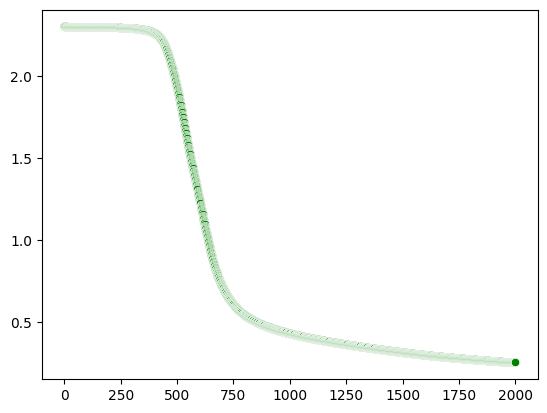

In [12]:
import seaborn as sns

sns.scatterplot(x=np.arange(0,ITERATIONS), y=J_history, color="green")

In [13]:
def nnw_calc(t1,t2,t3,X):
    fwd = forward_pass(t1,t2,t3,X)
    pred = []
    for i in range(fwd.shape[0]):
        pred.append(np.argmax(fwd[i]))
    return pred

In [14]:
predArr = nnw_calc(theta_1,theta_2,theta_out,X_test) #np.array([])
#for i in range(X_test.shape[0]):
#    np.append(predArr, nnw_calc(theta_1, theta_2, theta_out, X_test[i]))
print(predArr, Y_test)

[np.int64(3), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(2), np.int64(1), np.int64(3), np.int64(1), np.int64(4), np.int64(3), np.int64(5), np.int64(3), np.int64(6), np.int64(1)] [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
print(X_test[:1])

In [ ]:
print(X[:1])